In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


Este dataset contiene información técnica y ambiental sobre distintos tramos de carretera, con el objetivo de evaluar su estado y determinar si requieren mantenimiento urgente. Cada fila representa un segmento único de carretera, identificado por un Segment ID.

El objetivo del análisis es construir un modelo predictivo capaz de estimar si un segmento requiere mantenimiento urgente (Needs Maintenance = 1) o no (= 0), basándose en las demás variables. Esta es una tarea de clasificación supervisada binaria.

No conforme con esta predicción binaria, ajstamos una red neuronal feed forward para predecir el PCI, variable numérica que toma valores del 0 al 100 midiendo el estado de la carretera.


# Carga datos

### Descripción de las columnas del conjunto de datos

| Nombre de la Columna       | Descripción                                                                 |
|----------------------------|------------------------------------------------------------------------------|
| Segment ID                 | Identificador único del tramo de carretera                                  |
| PCI                        | Índice de Condición del Pavimento (0 = peor, 100 = mejor)                    |
| Road Type                  | Tipo de carretera (Principal, Secundaria, Barangay)                         |
| AADT                       | Tráfico Diario Promedio Anual                                               |
| Asphalt Type              | Clasificación de la mezcla asfáltica (ej. Densa, Abierta, SMA)              |
| Last Maintenance           | Año del último mantenimiento mayor                                          |
| Average Rainfall           | Promedio de lluvia anual en la zona (mm)                                    |
| Rutting                    | Profundidad de ahuellamiento (mm)                                           |
| IRI                        | Índice Internacional de Rugosidad (m/km)                                    |
| Needs Maintenance          | Etiqueta objetivo: 1 si se necesita mantenimiento urgente, 0 en caso contrario |


In [2]:
df = pd.read_csv("dataset/PavementDataset.csv")  # o el nombre real del archivo
df.head()

,Segment ID,PCI,Road Type,AADT,Asphalt Type,Last Maintenance,Average Rainfall,Rutting,IRI,Needs Maintenance
0,SID 155440,70.00,Secondary,4634,Concrete,2022,42.07,15.11,0.68,0
1,SID 244365,37.87,Tertiary,3474,Asphalt,2017,79.60,19.67,0.99,1
2,SID 137867,88.32,Tertiary,1734,Concrete,2019,62.69,14.73,0.50,0
3,SID 540519,52.30,Tertiary,3119,Asphalt,2008,79.32,17.01,1.04,1
4,SID 745776,49.10,Tertiary,3505,Asphalt,2019,71.81,21.08,1.18,1


In [8]:
# Información general del dataset
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df.shape}")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)
print("\n=== VALORES FALTANTES ===")
print(df.isnull().sum())
print("\n=== VALORES ROAD  ===")
print(df['Road Type'].value_counts())
print("\n=== VALORES ASFALTO  ===")
print(df['Asphalt Type'].value_counts())

=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: (1050000, 10)
Memoria utilizada: 228.85 MB

=== TIPOS DE DATOS ===
Segment ID            object
PCI                  float64
Road Type             object
AADT                   int64
Asphalt Type          object
Last Maintenance       int64
Average Rainfall     float64
Rutting              float64
IRI                  float64
Needs Maintenance      int64
dtype: object

=== VALORES FALTANTES ===
Segment ID           0
PCI                  0
Road Type            0
AADT                 0
Asphalt Type         0
Last Maintenance     0
Average Rainfall     0
Rutting              0
IRI                  0
Needs Maintenance    0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS ===

=== VALORES ROAD  ===
Road Type
Tertiary     489465
Secondary    332725
Primary      227810
Name: count, dtype: int64

=== VALORES ASFALTO  ===
Asphalt Type
Concrete    525294
Asphalt     524706
Name: count, dtype: int64


In [87]:
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().round(2)


=== ESTADÍSTICAS DESCRIPTIVAS ===


,PCI,AADT,Average Rainfall,Rutting,IRI,Needs Maintenance,Years Since Maintenance
count,1050000.00,1050000.00,1050000.00,1050000.00,1050000.00,1050000.0,1050000.00
mean,54.71,11556.83,64.98,16.59,0.85,0.5,6.85
std,28.78,13890.92,18.03,2.89,0.24,0.5,4.98
min,0.00,-19313.00,0.00,7.22,-0.28,0.0,-3.00
25%,29.98,2288.00,49.96,14.00,0.69,0.0,4.00
50%,55.02,5307.00,64.97,17.03,0.85,0.0,6.00
75%,80.07,16441.00,80.03,19.20,1.01,1.0,8.00
max,100.00,200150.00,129.84,24.09,1.91,1.0,66.00


Por suerte no encontramos valores nulos, sino habria que tratarlos usando la media o interpolando.

# Estudio de la correlación

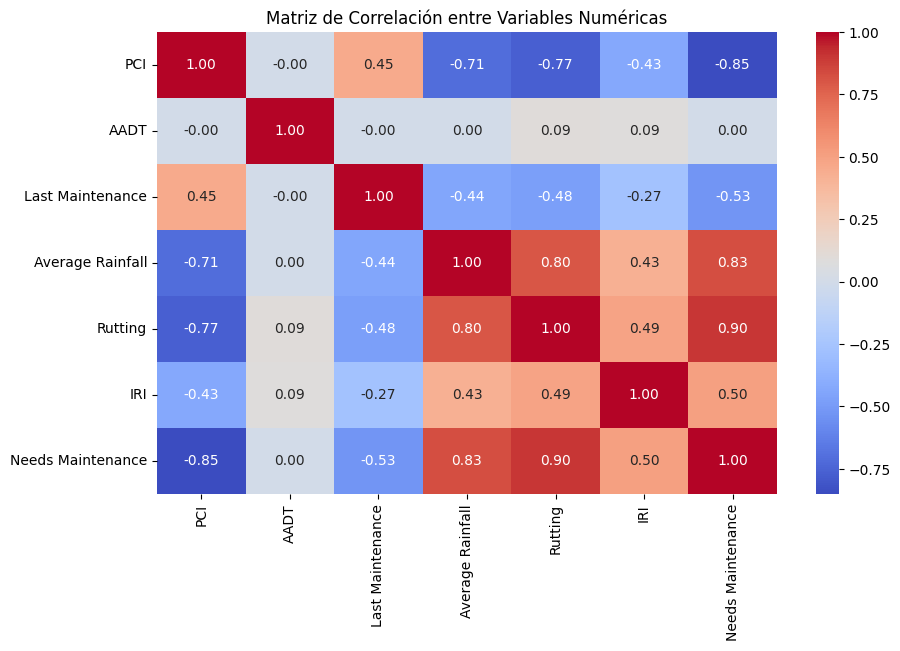

Determinante de la matriz de correlación: 0.007671


In [18]:
df_numerico = df.select_dtypes(exclude=['object'])
correlacion = df_numerico.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

# Calcular el determinante
determinante = np.linalg.det(correlacion)

print(f"Determinante de la matriz de correlación: {determinante:.6f}")

Vemos que el determinante es cercano a 0, luego hay multicolinealidad. Para tratarla, podemos probar a quitar algunas caracteristicas, e ir probando, pero optaremos por una analisis PCA.

Pero antes transformemos las caracteristicas predictivas.

## Transformaciones de caracteristicas

### LAST MAINTENANCE

En vez de usar el año, usamos la cantidad de años que lleva sin tener una revisión.

In [20]:
import datetime
df['Years Since Maintenance'] = datetime.datetime.now().year - df['Last Maintenance']
df.drop('Last Maintenance', axis=1, inplace=True)

### Variables categoricas

In [23]:
df = pd.get_dummies(df, columns=['Road Type', 'Asphalt Type'], drop_first=True)

### QUITAR ID

In [26]:
df =  df.drop(['Segment ID'], axis = 1)

## Dataset final 

In [28]:
X = df.drop(['Needs Maintenance'], axis=1)
y = df['Needs Maintenance']

### PCA

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Varianza explicada con 4 autovalores: 0.8330922698335456


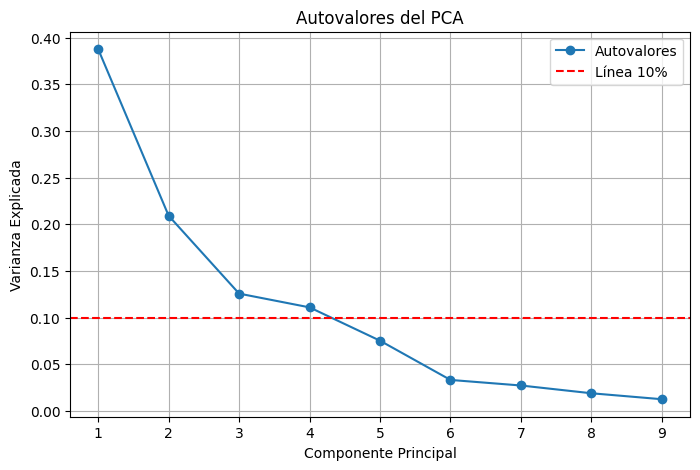

In [39]:
# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA (todos los componentes para ver autovalores)
pca = PCA()
pca.fit(X_scaled)

# Obtener autovalores (varianza explicada por cada componente)
eigenvalues = pca.explained_variance_ratio_
print(f'Varianza explicada con 4 autovalores: {np.sum(eigenvalues[:4])}')

# Gráfico de autovalores
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='o', label='Autovalores')
plt.axhline(y=0.10, color='red', linestyle='--', label='Línea 10%')
plt.title('Autovalores del PCA')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.legend()
plt.grid(True)
plt.show()

Me quedaria con estos 4 autovalores, no hay que olvidar que el análisis PCA nos da una combinación de las caracteristicas, con lo cual perdemos explicabilidad pues cada eje, es la combinación de estas caracteristicas y no solo una de ellas.

Igualmente intentemos representarlas y ver que significa cada una.

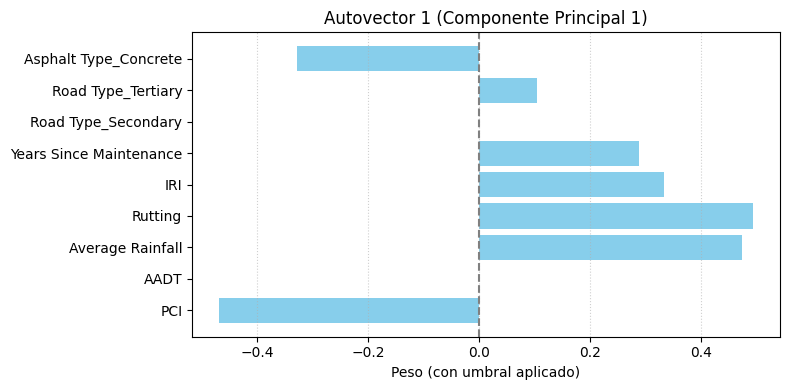

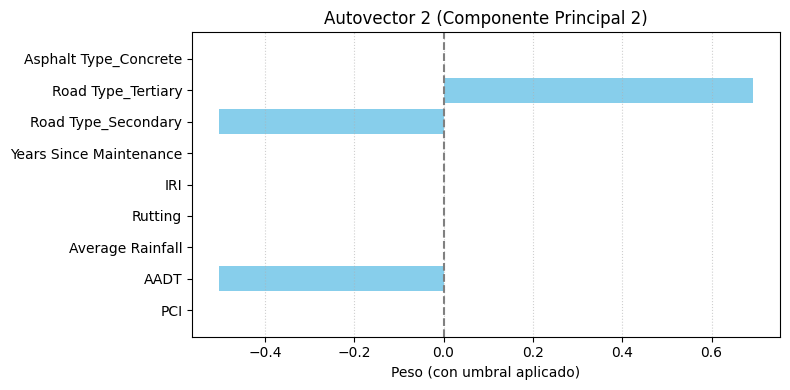

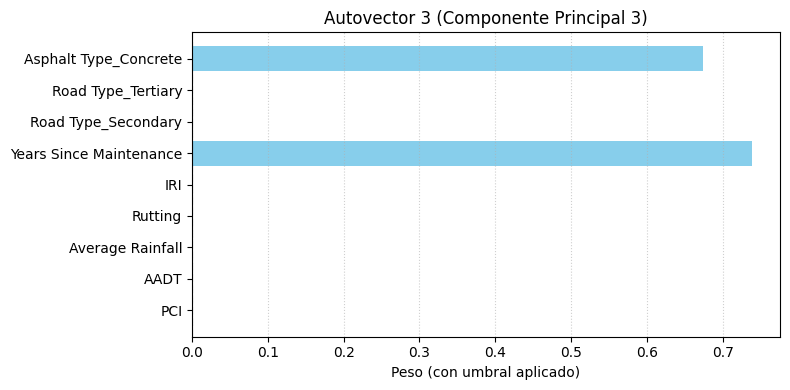

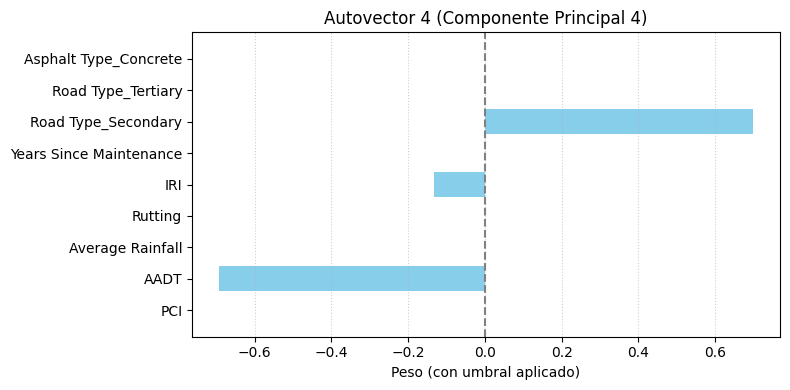

In [ ]:
componentes = pca.components_ # Autovectores, donde cada posicion del vector mide la importancia de su columna correspondiente.

# Filtramos para quedarnos con las componentes que de verdad influyen
filtrados = np.where(np.abs(componentes[:4]) > 0.1, componentes[:4], 0)

# Crear gráfico para cada componente
for i in range(4):
        pesos = filtrados[i]

        plt.figure(figsize=(8, 4))
        plt.barh(X.columns, pesos, color='skyblue')
        plt.axvline(x=0, color='gray', linestyle='--')
        plt.title(f'Autovector {i+1} (Componente Principal {i+1})')
        plt.xlabel('Peso (con umbral aplicado)')
        plt.tight_layout()
        plt.grid(axis='x', linestyle=':', alpha=0.6)
        plt.show()

Representemos los puntos en 3D con las primeras 3 componentes

In [56]:
from mpl_toolkits.mplot3d import Axes3D

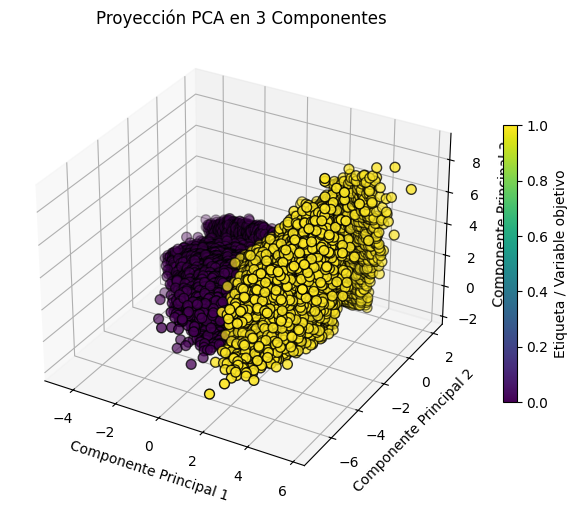

In [57]:
X_pca = pca.fit_transform(X_scaled)   # Conversion de los puntos segun los autovectores

# Crear figura y eje 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Suponiendo que 'y' es la variable para colorear (clases o target)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=y, cmap='viridis', s=50, edgecolor='k')

# Etiquetas y título
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('Proyección PCA en 3 Componentes')

# Añadir barra de color
cbar = fig.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label('Etiqueta / Variable objetivo')

plt.show()

Vemos una clara separación entre los datos, un algortimo lineal podria bastarnos para la clasificación

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizamos los datos segun X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo de regresión logística
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Evaluación del modelo
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

Matriz de confusión:
[[105021      5]
 [     2 104972]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    105026
           1       1.00      1.00      1.00    104974

    accuracy                           1.00    210000
   macro avg       1.00      1.00      1.00    210000
weighted avg       1.00      1.00      1.00    210000

ROC AUC Score: 0.9999999968253966


In [70]:
errores = np.where(np.where(np.abs(y_test-y_pred) > 0, 1,0)==1) # Indices donde ha fallado

In [80]:
df_errores = X_test.iloc[errores]
df_errores['Mantenimiento'] = y_test.iloc[errores]
df_errores

C:\Users\pablo\AppData\Local\Temp\ipykernel_7332\1752047455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_errores['Mantenimiento'] = y_test.iloc[errores]


,PCI,AADT,Average Rainfall,Rutting,IRI,Years Since Maintenance,Road Type_Secondary,Road Type_Tertiary,Asphalt Type_Concrete,Mantenimiento
511339,54.79,25067,65.73,18.44,0.93,9,True,False,True,1
580983,34.35,10263,75.42,17.36,0.66,1,True,False,False,0
373075,48.20,34901,63.58,18.42,1.13,2,False,False,False,0
83247,25.56,1344,56.11,17.45,0.73,2,False,True,False,0
883892,40.87,27827,64.41,15.68,1.28,11,True,False,True,0
359398,19.39,1363,56.88,17.01,1.13,1,False,True,False,0
910631,50.50,5937,68.44,19.39,0.92,7,True,False,True,1


Simplemente veo que el PCI es muy bajo aunque se haya hecho un mantenimiento hace 1 y 2 años. Me hace fijarme en el tipo de asfalto y veo que no es de hormigon, luego esa puede ser la causa.

Tambien es normal que haya fallado en una carretera que lleva 11 años sin hacerse un mantenimiento. 


# Red Neuronal

Como preveiamos es demasiado sencillo, intentaremos predecir ahora el PCI

In [117]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score

In [100]:
y_nn = X['PCI']
X_nn = X.assign(Mantenimiento = y).drop(['PCI'],axis=1)
X_nn.columns, y_nn.name

(Index(['AADT', 'Average Rainfall', 'Rutting', 'IRI', 'Years Since Maintenance',
        'Road Type_Secondary', 'Road Type_Tertiary', 'Asphalt Type_Concrete',
        'Mantenimiento'],
       dtype='object'),
 'PCI')

In [102]:
# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Normalizamos los datos segun X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # salida para regresión, sin activación
])

C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entrenar modelo
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=5, batch_size=32)

# Evaluar modelo
y_pred = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"R2 score: {r2:.3f}")

Epoch 1/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 22s 998us/step - loss: 229.3806 - mae: 12.3312 - val_loss: 229.8335 - val_mae: 12.3881
Epoch 2/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 21s 984us/step - loss: 229.7370 - mae: 12.3376 - val_loss: 228.0603 - val_mae: 12.3065
Epoch 3/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 21s 993us/step - loss: 228.4774 - mae: 12.2991 - val_loss: 228.3748 - val_mae: 12.2922
Epoch 4/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 21s 981us/step - loss: 228.4257 - mae: 12.3005 - val_loss: 229.0118 - val_mae: 12.3372
Epoch 5/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 21s 983us/step - loss: 229.0691 - mae: 12.3166 - val_loss: 229.3256 - val_mae: 12.3052
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 3s 505us/step
MSE: 229.984
R2 score: 0.722


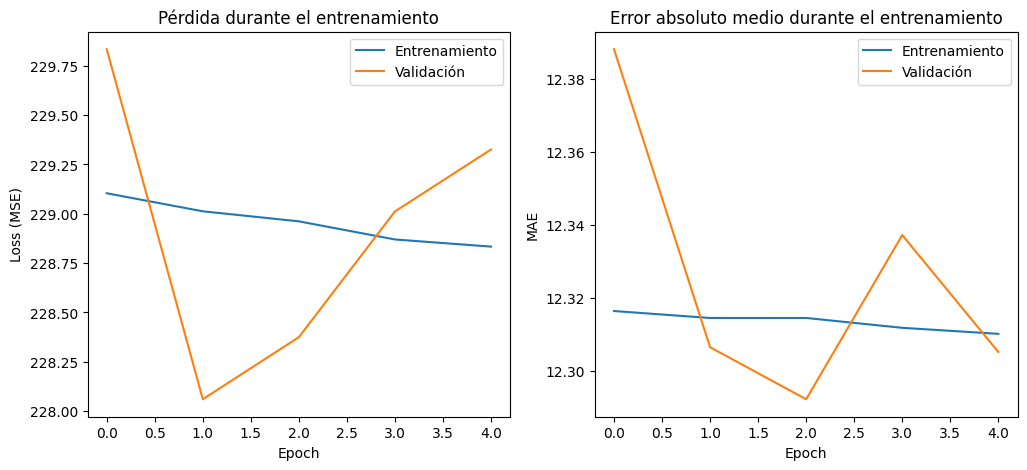

In [ ]:

history_dict = history.history

# Pérdida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Entrenamiento')
plt.plot(history_dict['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE
plt.subplot(1, 2, 2)
plt.plot(history_dict['mae'], label='Entrenamiento')
plt.plot(history_dict['val_mae'], label='Validación')
plt.title('Error absoluto medio durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

Tras 5 epocas vemos que se esta sobreentrenando luego. Veamos cuales son los mejores parametros para esto.
Como hemos visto en clase usemos optimizacion bayesiana, la variante de TPE, que mediante dos distribuciones de probabilidad que miden los mejores resultados y el resto, propone los siguientes parametros prometedores a probar.

## Optimizacion Bayesiana

In [110]:
import optuna

In [119]:
# def create_model(trial):
#     model = Sequential()
#     n_layers = trial.suggest_int("n_layers", 1, 3)
#     for i in range(n_layers):
#         num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 128, step=16)
#         if i == 0:
#             model.add(Dense(num_hidden, activation="relu", input_shape=(X_train_scaled.shape[1],)))
#         else:
#             model.add(Dense(num_hidden, activation="relu"))

#         dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.5)
#         if dropout_rate > 0:
#             model.add(Dropout(dropout_rate))
            
#     model.add(Dense(1))  # Salida para regresión
#     learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
#     model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
#     return model

# def objective(trial):
#     model = create_model(trial)
#     history = model.fit(X_train_scaled, y_train, epochs=3, batch_size=32,
#                         validation_data=(X_test_scaled, y_test), verbose=1)
#     preds = model.predict(X_test_scaled).flatten()
#     mse = mean_squared_error(y_test, preds)
#     return mse

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
# study.optimize(objective, n_trials=30)

# print("Mejores hiperparámetros:")
# print(study.best_params)

[I 2025-06-20 21:12:52,817] A new study created in memory with name: no-name-398cfad4-834d-43b6-bd0b-3e8f6bf243a6


Epoch 1/3


C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26250/26250 ━━━━━━━━━━━━━━━━━━━━ 28s 1ms/step - loss: 366.6740 - val_loss: 229.5157
Epoch 2/3
26250/26250 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 256.2149 - val_loss: 229.0963
Epoch 3/3
26250/26250 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 254.7226 - val_loss: 231.3383
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 3s 516us/step


[I 2025-06-20 21:14:20,194] Trial 0 finished with value: 231.33796528836527 and parameters: {'n_layers': 2, 'n_units_l0': 128, 'dropout_l0': 0.10008721447000418, 'n_units_l1': 112, 'dropout_l1': 0.2890323456426402, 'learning_rate': 0.00043198517193504093}. Best is trial 0 with value: 231.33796528836527.


...

Epoch 1/3


C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26250/26250 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 686.8212 - val_loss: 235.9707
Epoch 2/3
26250/26250 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 356.4746 - val_loss: 233.2428
Epoch 3/3
26250/26250 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 346.6887 - val_loss: 233.3299
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 3s 521us/step


[I 2025-06-20 21:55:20,318] Trial 29 finished with value: 233.32974641245906 and parameters: {'n_layers': 2, 'n_units_l0': 96, 'dropout_l0': 0.13326945328100614, 'n_units_l1': 48, 'dropout_l1': 0.47071387674211035, 'learning_rate': 0.00015782402435208552}. Best is trial 19 with value: 228.20809550217726.


Mejores hiperparámetros:
{'n_layers': 1, 'n_units_l0': 112, 'dropout_l0': 0.2790733750221323, 'learning_rate': 0.0007639958491437932}


### Tras la optimazion vemos que no ha cambiado mucho el MSE, vamos de 229 a 228.

## PCA Red Neuronal

In [124]:
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# Tomemos las mejores caracteristicas de la busqueda de TPE, aunque el rendimiento no ha mejorado mucho. Se ve que el problema es complejo.

In [125]:
model_pca = Sequential([
    Dense(112, input_dim=X_train_pca.shape[1], activation='relu'),
    Dropout(0.27),  # correctamente definido dentro de la lista
    Dense(1)  # salida para regresión
])

C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_pca.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
# Entrenar modelo
history = model_pca.fit(X_train_pca, y_train, validation_split=0.2, epochs=3, batch_size=32)

In [132]:
# Evaluar modelo
y_pred = model_pca.predict(X_test_pca).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"R2 score: {r2:.3f}")

6563/6563 ━━━━━━━━━━━━━━━━━━━━ 3s 487us/step
MSE: 228.799
R2 score: 0.724


Nos fijamos en el R2 que mide la cantidad de varianza explicada, y vemos como en el anterior sin PCA obteniamos un 0.722 un poquito mas simplemente, probemos a entrenar mas.

Buscando informacion encuentro que la red neuronal ya hace una reduccion dimensionalidad internamento luego el PCA puede interferir en ella.


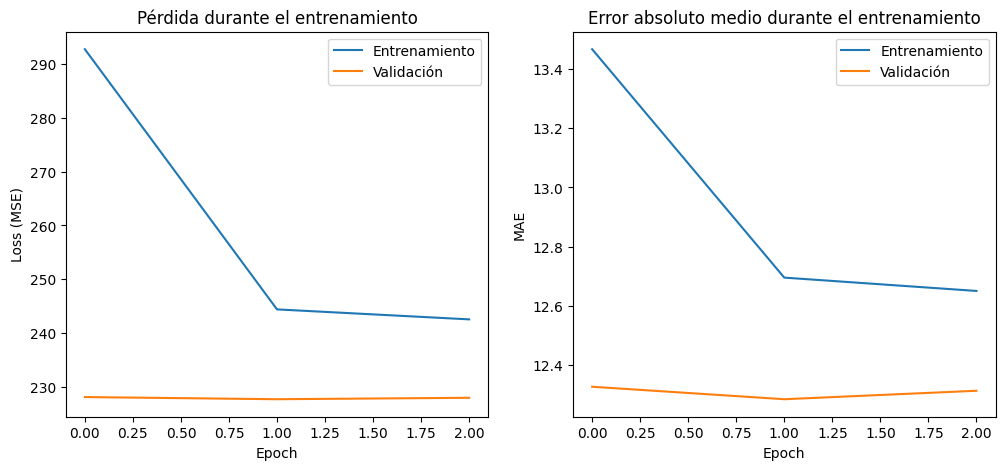

In [ ]:

history_dict = history.history

# Pérdida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Entrenamiento')
plt.plot(history_dict['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE
plt.subplot(1, 2, 2)
plt.plot(history_dict['mae'], label='Entrenamiento')
plt.plot(history_dict['val_mae'], label='Validación')
plt.title('Error absoluto medio durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [131]:
model_pca2 = Sequential([
    Dense(112, input_dim=X_train_pca.shape[1], activation='relu'),
    Dropout(0.27), 
    Dense(20,activation='relu'),
    Dropout(0.27), 
    Dense(1)  # salida para regresión
])

C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [133]:
model_pca2.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
# Entrenar modelo
history = model_pca2.fit(X_train_pca, y_train, validation_split=0.2, epochs=5, batch_size=32)

# Evaluar modelo
y_pred = model_pca2.predict(X_test_pca).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"R2 score: {r2:.3f}")

Epoch 1/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 461.3596 - mae: 16.3780 - val_loss: 236.5090 - val_mae: 12.5812
Epoch 2/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 311.3935 - mae: 14.1819 - val_loss: 231.2543 - val_mae: 12.4354
Epoch 3/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 290.5357 - mae: 13.7375 - val_loss: 227.5699 - val_mae: 12.2821
Epoch 4/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 277.2630 - mae: 13.4580 - val_loss: 228.3209 - val_mae: 12.3381
Epoch 5/5
21000/21000 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 268.9216 - mae: 13.2668 - val_loss: 227.7195 - val_mae: 12.2792
6563/6563 ━━━━━━━━━━━━━━━━━━━━ 4s 527us/step
MSE: 228.469
R2 score: 0.724


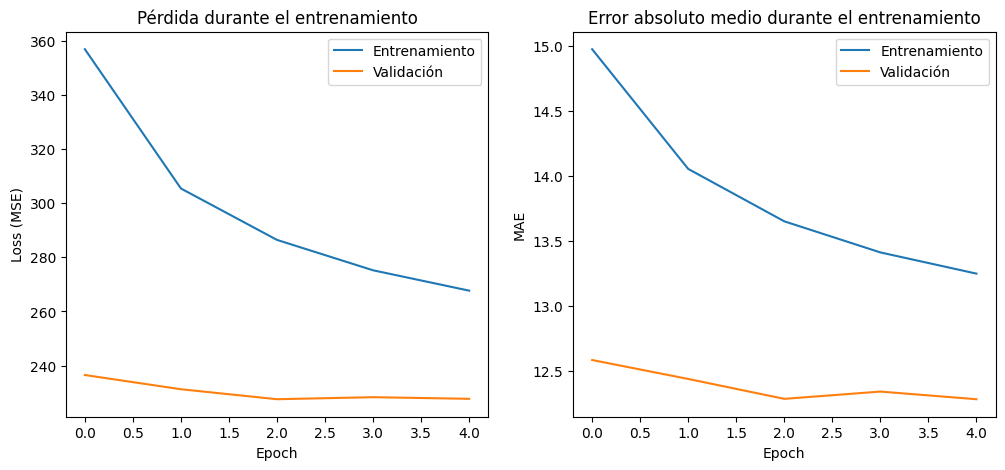

In [ ]:

history_dict = history.history

# Pérdida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Entrenamiento')
plt.plot(history_dict['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE
plt.subplot(1, 2, 2)
plt.plot(history_dict['mae'], label='Entrenamiento')
plt.plot(history_dict['val_mae'], label='Validación')
plt.title('Error absoluto medio durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [ ]:
Esto nos dice que podriamos seguir entrenando. Que todavia hay margen de mejora.

# Observacion final

En este trabajo hemos tratado un dataset de carreteras, y hemos medido tanto su revision inminente como su indice de estado, con un algoritmo de clasificacion y otro de regresion.


Obteniendo para la calsificacion casi un 100%.

Y para la regresion un R2 del 72%. Todavia con margen de mejora.

Pedro Delgado Jimenez